Our conclusion is that the AllSky camera data we have is unsuitable for our analysis. The imagery from the time period of interest was stored as JPG. This format does not provide the necessary metadata and resolution for our analysis, which requires high-quality, uncompressed image data with information saved in the header.

Initially, we attempted to find a calibration that would allow us to use the image pixel brightnesses as a metric that would allow _relatively quantitative_ analysis of the sky brightness. i.e. to determine a relative change in pixel brightnesses, even if we couldn't get objective measurements of the sky brightness. Unfortunately, we can clearly see in the plot that the camera's settings were adjusted directly before, and possibly during the period of study we were interested in, invalidating this data source from our consideration.

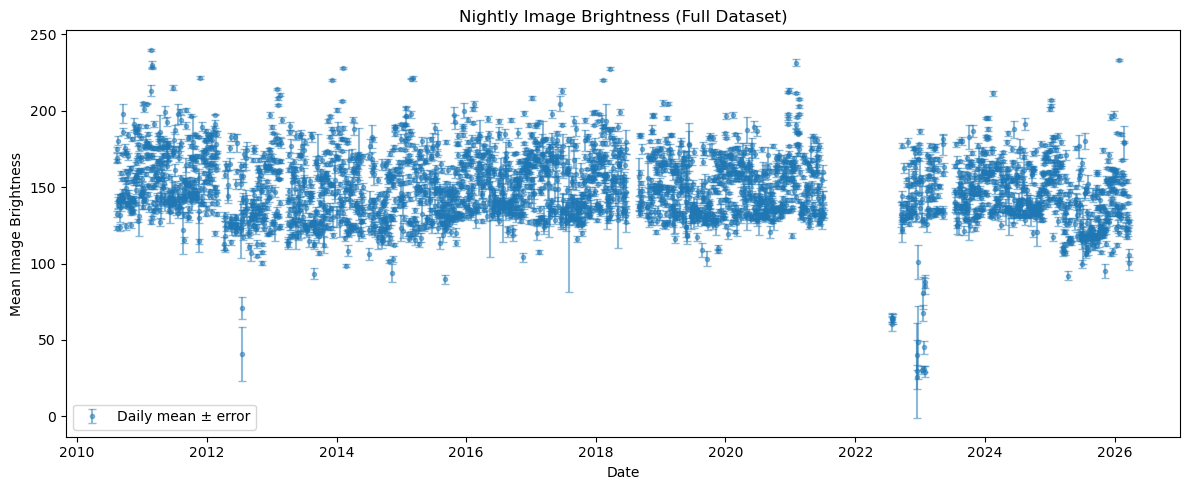

In [1]:
from pathlib import Path
import pandas as pd
from allsky.plotting import plot_brightness

image_location = Path("../../images/NightSkyImages/")
clear_image_location = Path("../../images/SelectedSkyImages/")
enriched_df_location = Path("../../data/enriched_df.parquet")

if (not image_location.exists()) or (not enriched_df_location.exists()):
    raise FileNotFoundError

enriched_df = pd.read_parquet(enriched_df_location)
_ = plot_brightness(enriched_df, "Full Dataset", plot_best_fit=False)

With the above plot, we were able to determine that we would need significant filtering of the dataset to the classic restrictions of completely clear nights. With more than 800 thousand dark-night images to filter to, we decided to limit the study to the time period between 21 March 2024 and onward (ending 26 March 2026).

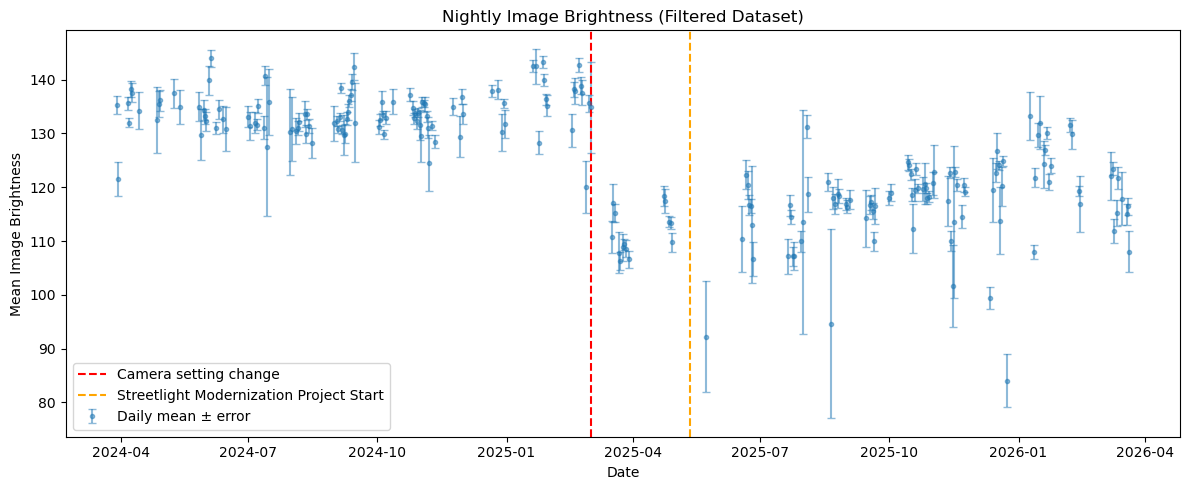

In [2]:
date_dt = pd.to_datetime(enriched_df["date"], format="%Y/%m/%d", errors="coerce")
recent_years_df = enriched_df[(date_dt >= pd.to_datetime("2024-03-21"))]
image_set = set(list([str(x) for x in clear_image_location.glob("20*-*/*.JPG")]))
condition = (
    recent_years_df["image_paths"]
    .str.replace(str(image_location), str(clear_image_location))
    .isin(image_set)
)
only_clear_nights_df = recent_years_df[condition]

ax = plot_brightness(only_clear_nights_df, "Filtered Dataset", plot_best_fit=False)
ax.axvline(
    pd.to_datetime("2025-03-02"),
    color="red",
    linestyle="--",
    label="Camera setting change",
)
ax.axvline(
    pd.to_datetime("2025-05-12"),
    color="orange",
    linestyle="--",
    label="Streetlight Modernization Project Start",
)
_ = ax.legend()

The plot above shows a sudden plummet in mean camera brightness that could not have been caused by the streetlight modernization project, as it happened in concert with some glitched camera images, and more than two months prior to the commencement of the modernization project. Although the slope of the image brightnesses may seem indicative after the project began, we cannot have confidence that the camera kept identical settings throughout the period of study, nor do we have a solid baseline. As such, we are rejecting this data source and will search for another data source that will answer our questions.